# Figure 4 visualization
Relationship between prediction loss and number of sensors for 4- and 8-input-source co-optimization runs.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
DATA_DIR = PROJECT_ROOT / "data"

plt.rcParams.update({
    "axes.grid": False,
    "figure.figsize": (7, 4),
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 8,
})
COLORS = ["#cc3f40", "#bdccd4", "#0b2456", "#2980b9", "#00a043"]


In [2]:
data = np.load(DATA_DIR / 'figure4_sensor_count_losses.npz')
print('keys:', data.files)
for key in data.files:
    print(key, data[key].shape)

keys: ['source4_initial_loss', 'source4_optimized_loss', 'source8_initial_loss', 'source8_optimized_loss']
source4_initial_loss (6, 5)
source4_optimized_loss (6, 5)
source8_initial_loss (6, 5)
source8_optimized_loss (6, 5)


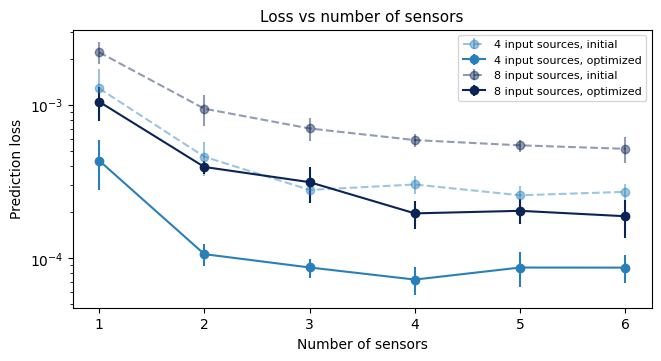

In [3]:
sensor_counts = np.arange(1, data['source4_initial_loss'].shape[0] + 1)
fig, ax = plt.subplots(figsize=(6.5, 3.5), constrained_layout=True)
for prefix, label, color in [('source4', '4 input sources', COLORS[3]), ('source8', '8 input sources', COLORS[2])]:
    init = data[f'{prefix}_initial_loss']
    opt = data[f'{prefix}_optimized_loss']
    ax.errorbar(sensor_counts, init.mean(axis=1), yerr=init.std(axis=1), marker='o', color=color, alpha=0.45, linestyle='--', label=f'{label}, initial')
    ax.errorbar(sensor_counts, opt.mean(axis=1), yerr=opt.std(axis=1), marker='o', color=color, label=f'{label}, optimized')
ax.set_yscale('log')
ax.set_xlabel('Number of sensors')
ax.set_ylabel('Prediction loss')
ax.set_title('Loss vs number of sensors')
ax.legend()
plt.show()